# Estimating the model parameters

The model from [the previous notebook](nb06-splink-settings-and-blocking.ipynb)
runs, but it does not know anything about your data: its *m* values are Splink's
defaults.

This notebook estimates the three parameters that make it a model of *these*
registers, checks the estimates against the values computed by hand in chapter
2.4, and saves the result.

**What you will do**

1. Rebuild the model from chapter 2.6
2. Estimate λ, the prior probability that two random records match
3. Estimate *u* by random sampling
4. Estimate *m* by expectation-maximisation, without a ground truth
5. Compare the estimates with the hand-computed values from chapter 2.4
6. Re-predict, and finally measure the payoff of fuzzy comparison
7. Save the trained model

## 0. Setup and model definition

In [1]:
import unicodedata
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

DATA = Path("../../data")
if not DATA.exists():
    DATA = Path("data")

fonasa = pd.read_csv(DATA / "fonasa_sample.csv", dtype=str)
suseso = pd.read_csv(DATA / "suseso_sample.csv", dtype=str)


def basic_text_clean(series):
    return (series.astype("string").str.strip().str.upper()
            .str.replace(r"\s+", " ", regex=True))


def remove_accents(value):
    if pd.isna(value):
        return pd.NA
    value = unicodedata.normalize("NFKD", str(value))
    return "".join(c for c in value if not unicodedata.combining(c))


def standardise_name(series):
    cleaned = basic_text_clean(series)
    cleaned = cleaned.map(remove_accents, na_action="ignore").astype("string")
    cleaned = cleaned.str.replace(r"[^A-ZN ]", "", regex=True)
    return cleaned.str.replace(r"\s+", " ", regex=True).str.strip()


def clean_sex(series):
    cleaned = basic_text_clean(series)
    return cleaned.replace({"HOMBRE": "M", "MUJER": "F", "MASCULINO": "M",
                            "FEMENINO": "F", "": pd.NA})


for df in (fonasa, suseso):
    for col in ["nombre", "ap1", "ap2"]:
        df[f"{col}_clean"] = standardise_name(df[col])
    df["sexo_clean"] = clean_sex(df["sexo"])
    df["nac_clean"] = basic_text_clean(df["nacionalidad"])

CLEAN = ["nombre_clean", "ap1_clean", "ap2_clean", "sexo_clean", "nac_clean"]
TRUE_MATCHES = 4500

print(f"fonasa: {len(fonasa):,} records | suseso: {len(suseso):,} records")
print(f"true matches present in the data: {TRUE_MATCHES:,}")


import phonetics


def dmeta_primary(value):
    """Primary Double Metaphone code, as a string. Used for blocking."""
    if pd.isna(value) or value == "":
        return None
    try:
        return phonetics.dmetaphone(str(value))[0] or None
    except Exception:
        return None


def dmeta_list(value):
    """Both Double Metaphone codes, as a list. This is the form Splink's
    comparison functions expect for a `dmeta_col_name` argument."""
    if pd.isna(value) or value == "":
        return None
    try:
        return [c for c in phonetics.dmetaphone(str(value)) if c] or None
    except Exception:
        return None


for df in (fonasa, suseso):
    for col in ["nombre_clean", "ap1_clean", "ap2_clean"]:
        stem = col.replace("_clean", "")
        df[f"{stem}_dm"] = df[col].map(dmeta_primary)      # string, for blocking
        df[f"{stem}_dmeta"] = df[col].map(dmeta_list)      # list, for comparisons

MODEL_COLS = (["unique_id"] + CLEAN
              + ["nombre_dm", "ap1_dm", "ap2_dm"]
              + ["nombre_dmeta", "ap1_dmeta", "ap2_dmeta"])
fonasa_m = fonasa[MODEL_COLS + ["true_person_id"]].copy()
suseso_m = suseso[MODEL_COLS + ["true_person_id"]].copy()

print("phonetic example:  GONZALEZ ->",
      dmeta_primary("GONZALEZ"), "(blocking) /", dmeta_list("GONZALEZ"), "(comparison)")

fonasa: 30,000 records | suseso: 27,000 records
true matches present in the data: 4,500
phonetic example:  GONZALEZ -> KNSLS (blocking) / ['KNSLS'] (comparison)


In [2]:
from splink import DuckDBAPI, Linker, SettingsCreator, block_on
import splink.comparison_library as cl

blocking_rules = [
    block_on("nombre_clean", "ap1_clean"),
    block_on("ap1_clean", "ap2_clean"),
    block_on("substr(nombre_clean,1,1)", "ap1_clean", "ap2_clean"),
    block_on("ap1_dm", "ap2_dm"),
    block_on("nombre_dm", "ap1_dm"),
    block_on("substr(nombre_clean,1,1)", "ap1_dm", "ap2_dm"),
]

comparisons = [
    cl.NameComparison("nombre_clean", dmeta_col_name="nombre_dmeta")
        .configure(term_frequency_adjustments=True),
    cl.NameComparison("ap1_clean", dmeta_col_name="ap1_dmeta")
        .configure(term_frequency_adjustments=True),
    cl.NameComparison("ap2_clean", dmeta_col_name="ap2_dmeta")
        .configure(term_frequency_adjustments=True),
    cl.ExactMatch("sexo_clean"),
    cl.ExactMatch("nac_clean").configure(term_frequency_adjustments=True),
]

settings = SettingsCreator(
    link_type="link_only",
    blocking_rules_to_generate_predictions=blocking_rules,
    comparisons=comparisons,
    unique_id_column_name="unique_id",
    retain_intermediate_calculation_columns=True,
    # Carried through to the output for evaluation only. It is never compared,
    # never blocked on, and would not exist in real data.
    additional_columns_to_retain=["true_person_id"],
)

linker = Linker(
    input_table_or_tables=[fonasa_m, suseso_m],
    settings=settings,
    db_api=DuckDBAPI(),
    input_table_aliases=["fonasa", "suseso"],
)
print("linker rebuilt with", len(blocking_rules), "blocking rules and",
      len(comparisons), "comparisons")

linker rebuilt with 6 blocking rules and 5 comparisons


In [3]:
import vl_convert as vlc
from IPython.display import Image


def show(chart, scale=2):
    """Render a Splink (Altair) chart as a static image.

    Splink returns interactive Altair charts. Rendering them to PNG keeps them
    visible in the published book; in your own session you can simply display
    the chart object and interact with it.
    """
    return Image(vlc.vegalite_to_png(chart.to_json(), scale=scale))

## 1. The three parameters

A Fellegi-Sunter model has exactly three things to learn, and they are learned in
three different ways because they are three different kinds of quantity.

| Parameter | What it is | How it is estimated |
|:--|:--|:--|
| **λ** | The probability that two randomly chosen records are a match | From a deterministic rule plus an assumed recall |
| ***u*** | For each comparison level, how often *non-matches* land there | By sampling random pairs — almost all of which are non-matches |
| ***m*** | For each comparison level, how often *matches* land there | By expectation-maximisation, because we have no labelled matches |

Chapter 2.4 computed all three directly, using the ground truth. The point of
this notebook is that none of the three needs it.

## 2. λ — the prior

λ is the probability that two records picked at random are the same person. It
sets the starting point of every score: with 810 million possible pairs and a few
thousand real matches, a pair starts out overwhelmingly likely to be a non-match,
and needs strong evidence to overcome that.

Splink estimates it from a rule you are confident about, plus an assumption
about what share of matches that rule finds.

In [4]:
deterministic_rules = [
    block_on("nombre_clean", "ap1_clean", "ap2_clean"),
    block_on("nombre_clean", "ap1_clean", "sexo_clean", "nac_clean"),
]

linker.training.estimate_probability_two_random_records_match(
    deterministic_rules, recall=0.5
)

Probability two random records match is estimated to be  3.01e-06.
This means that amongst all possible pairwise record comparisons, one in 332,512.32 are expected to match.  With 810,000,000 total possible comparisons, we expect a total of around 2,436.00 matching pairs


The `recall=0.5` argument is an assumption, and it is the weakest link in the
whole estimation. It says: *I believe these strict rules find about half of all
true matches.*

Chapter 2.4 measured the truth here — strict rules found roughly a quarter of the
matches — so 0.5 is optimistic. In real work you would justify this number from a
clerical sample or from experience with the same sources, and you would test how
much the final result moves if you change it. λ shifts every score by a constant,
so it moves the *threshold* you need, not the *ranking* of pairs.

## 3. u — by random sampling

*u* asks how often a comparison level occurs among **non**-matches. Since almost
every random pair is a non-match, sampling random pairs answers it directly.

Note that this must sample from *all* pairs, not from the candidate pairs. As the
previous notebook showed, blocking makes the candidate set unrepresentative by
design.

In [5]:
linker.training.estimate_u_using_random_sampling(max_pairs=5e6)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - nombre_clean (no m values are trained).
    - ap1_clean (no m values are trained).
    - ap2_clean (no m values are trained).
    - sexo_clean (no m values are trained).
    - nac_clean (no m values are trained).


```{warning}
`estimate_u_using_random_sampling()` draws a random sample and **is not fixed by
a seed**. Running this notebook twice gives slightly different *u* values, and
therefore slightly different scores and a slightly different optimal threshold.

This is a real reproducibility issue, not a rounding artefact, and chapter 3.1
treats it as one. It is also why the notebooks in this book are published with
the outputs of one specific run rather than re-executed on every build.
```

## 4. m — by expectation-maximisation

*m* is the hard one: it asks how often a level occurs among **matches**, and we
have no labelled matches.

Expectation-maximisation escapes the circularity by iterating. Start with a guess
at the parameters; use it to assign every pair a probability of being a match;
re-estimate the parameters treating those probabilities as weights; repeat until
they stop moving.

To make this work, EM is run on a **subset** of pairs blocked on some field, so
that the subset contains a reasonable mix of matches and non-matches. The field
used for that blocking cannot have its own *m* estimated in that session — it is
held fixed by construction — so you run several sessions with different training
rules and let them cover each other.

In [6]:
training_rules = [
    block_on("nombre_clean", "ap1_clean"),      # cannot train nombre or ap1
    block_on("ap1_clean", "ap2_clean"),         # cannot train ap1 or ap2
    block_on("nombre_clean", "sexo_clean"),     # cannot train nombre or sexo
]

for rule in training_rules:
    linker.training.estimate_parameters_using_expectation_maximisation(rule)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
(l."nombre_clean" = r."nombre_clean") AND (l."ap1_clean" = r."ap1_clean")

Parameter estimates will be made for the following comparison(s):
    - ap2_clean
    - sexo_clean
    - nac_clean

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - nombre_clean
    - ap1_clean

Iteration 1: Largest change in params was 0.0474 in the m_probability of nac_clean, level `Exact match on nac_clean`
Iteration 2: Largest change in params was 0.00847 in the m_probability of ap2_clean, level `All other comparisons`
Iteration 3: Largest change in params was 0.0073 in the m_probability of ap2_clean, level `All other comparisons`
Iteration 4: Largest change in params was 0.00573 in the m_probability of ap2_clean, level `All other comparisons`
Iteration 5: Largest change in params was 0.00408 in the m_probability of ap2_clean, level `All ot

Splink reports convergence for each session, and warns about any comparison level
it could not train. Read those warnings: a level with no estimate falls back to a
default, and you should know which parts of your model are guesses.

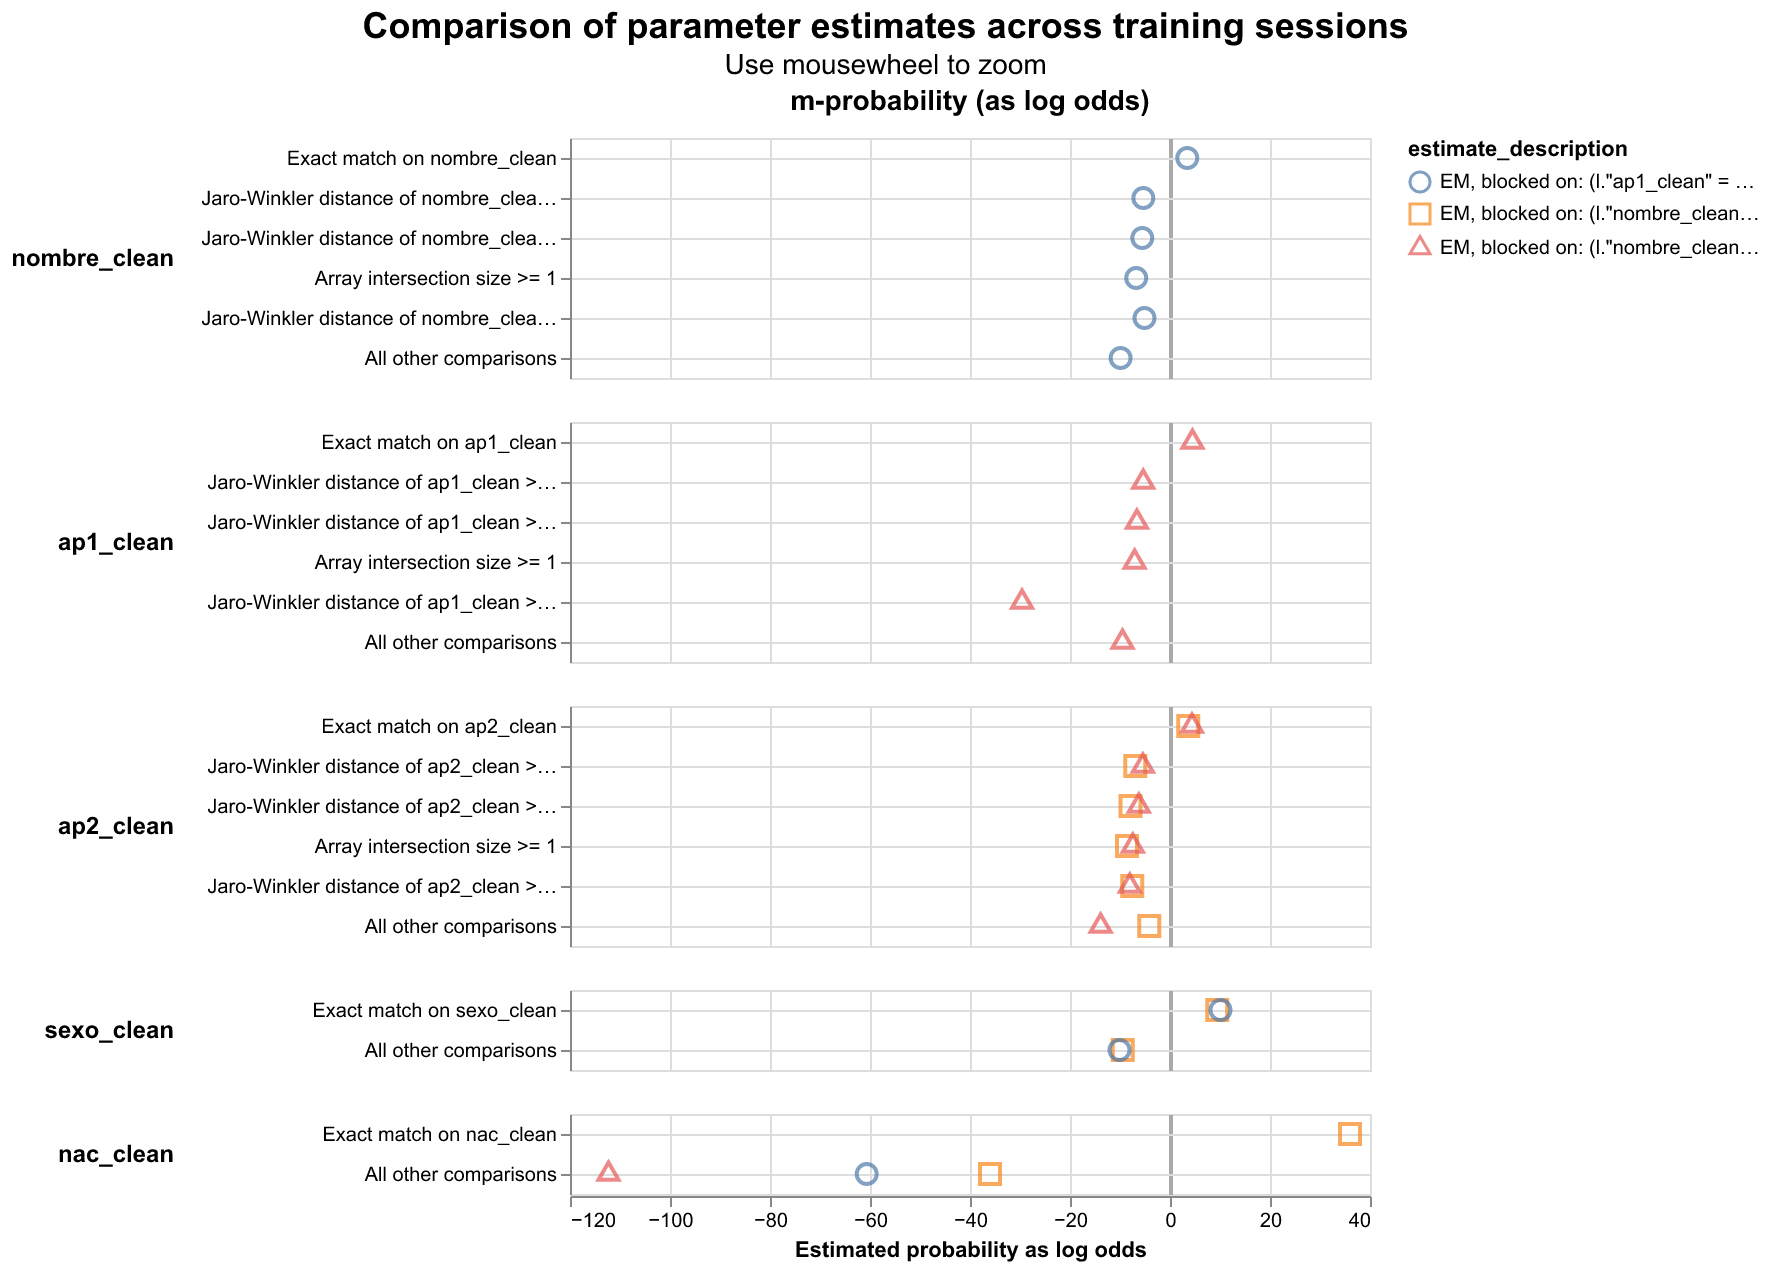

In [7]:
show(linker.visualisations.parameter_estimate_comparisons_chart())

Each row shows the estimates that different training sessions produced for the
same parameter. Where the sessions agree, the estimate is well identified. Where
they disagree, the parameter depends on which subset of pairs it was estimated
from, and deserves less confidence.

## 5. The trained model

The match-weights chart is the model in one picture: what each comparison level
is worth, in bits.

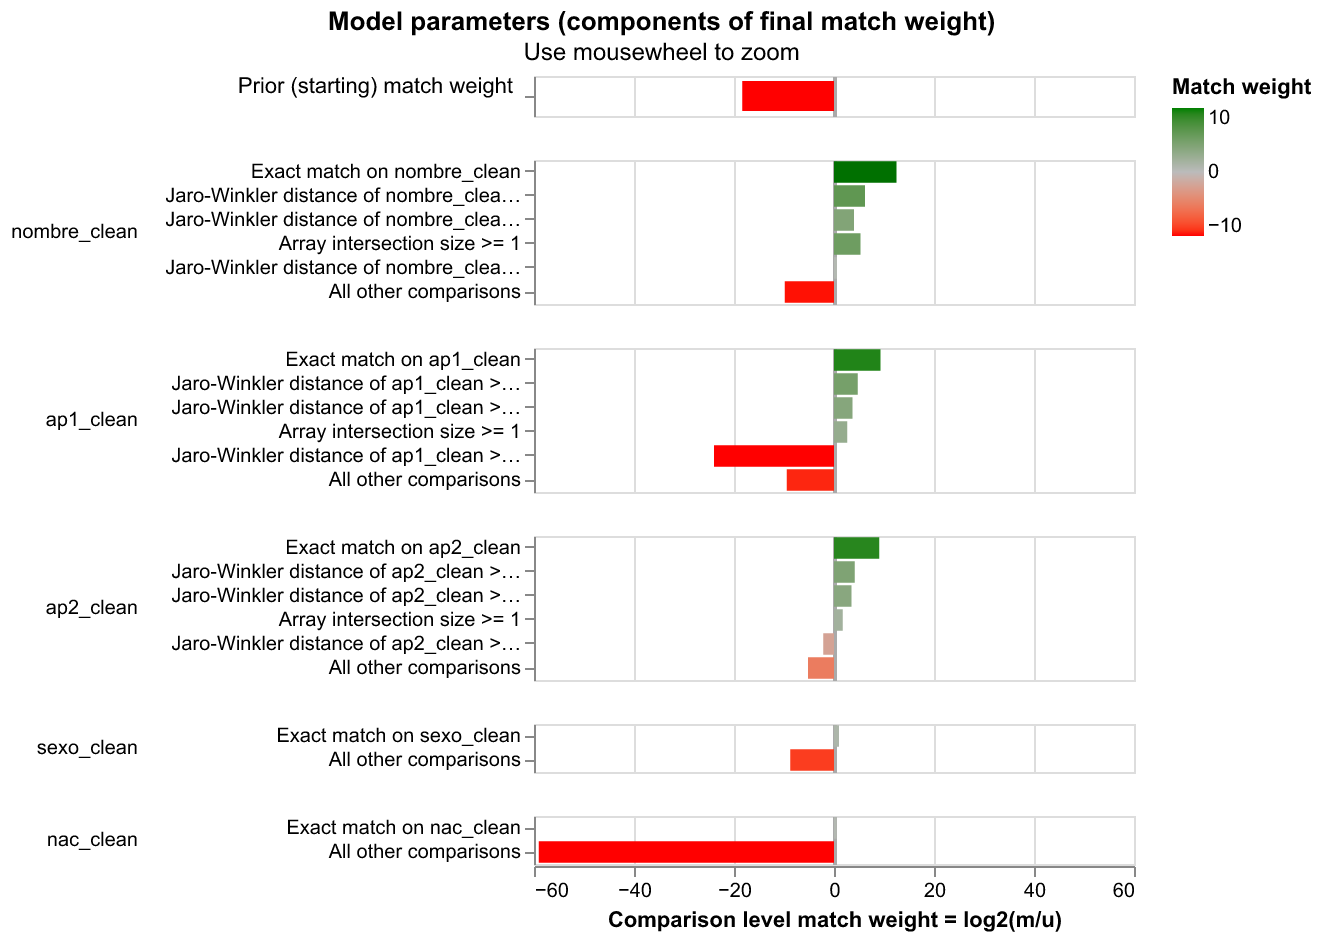

In [8]:
show(linker.visualisations.match_weights_chart())

The red bar at the top is the prior — the starting deficit every pair has to
overcome. Below it, each comparison contributes a positive weight when it agrees
and a negative one when it does not, with the intermediate similarity levels
sitting between the two extremes.

That gradation is the whole point of this chapter. In chapter 2.4 a name either
agreed or it did not. Here a nearly-agreeing name earns real positive evidence.

### Do the estimates match the truth?

We have an unusual luxury: chapter 2.4 computed *m* and *u* directly from the
4,500 known matches. Compare those with what EM produced without ever seeing
them.

In [9]:
params = pd.DataFrame(linker.misc.save_model_to_json()["comparisons"])

rows = []
for comp in linker._settings_obj.comparisons:
    col = comp.output_column_name
    for level in comp.comparison_levels:
        if level.is_null_level or level._is_else_level:
            continue
        if "Exact match" in str(level.label_for_charts):
            rows.append({
                "field": col,
                "level": "exact match",
                "m_estimated_by_EM": round(level.m_probability, 4),
                "u_estimated_by_sampling": round(level.u_probability, 6),
            })

comparison_table = pd.DataFrame(rows)

# the values computed by hand from the known matches in chapter 2.4
by_hand = pd.DataFrame({
    "field": ["nombre_clean", "ap1_clean", "ap2_clean", "sexo_clean", "nac_clean"],
    "m_measured_ch2_4": [0.3232, 0.4509, 0.4377, 0.9162, 0.9944],
    "u_measured_ch2_4": [0.000149, 0.001470, 0.001770, 0.500436, 0.670525],
})

comparison_table.merge(by_hand, on="field")

,field,level,m_estimated_by_EM,u_estimated_by_sampling,m_measured_ch2_4,u_measured_ch2_4
0,nombre_clean,exact match,0.9163,0.000158,0.3232,0.000149
1,ap1_clean,exact match,0.9574,0.001506,0.4509,0.001470
2,ap2_clean,exact match,0.9404,0.001748,0.4377,0.001770
3,sexo_clean,exact match,0.9988,0.499960,0.9162,0.500436
4,nac_clean,exact match,1.0000,0.674130,0.9944,0.670525


**The *u* estimates are excellent.** Every one is within a few percent of the
measured value. That is expected: random sampling answers "how often do two
different people agree on this?" directly, and there is very little that can go
wrong.

**The *m* estimates are nowhere near the measured values, and the gap is large.**
EM puts the exact-match *m* for the given name at around 0.92; measured against
the 4,500 known matches it is 0.32. EM is not slightly optimistic, it is
optimistic by a factor of three.

This is worth understanding rather than glossing over, because it is not a bug
and it will happen to you.

EM only ever sees **candidate pairs** — the 8,868 that survived blocking. And
blocking selected them precisely because their names agree well. Among *those*
pairs, a true match almost always agrees exactly on the given name, so 0.92 is
a correct answer to the question EM was actually asked. It is the wrong answer
to the question "how often do true matches in the *population* agree exactly",
because the true matches that disagree on names were filtered out before EM ever
saw them.

The same effect shows up in λ: the estimate implies about 2,400 matching pairs
in total, when there are 4,500.

Two consequences follow, and both matter.

*Do not read Splink's estimated parameters as population quantities.* They are
conditioned on the candidate set. Quoting an estimated *m* as "the accuracy of
this field in our register" would be wrong.

*Judge the model by how it ranks pairs, not by whether its parameters look
plausible.* A model with biased parameters can still separate matches from
non-matches perfectly well, because ranking depends on the *relative* weights.
Whether it does is an empirical question, which is what the next section and
chapter 2.8 answer.

## 6. Predicting with trained parameters

Now the payoff.

In [10]:
df_predict = linker.inference.predict()
predictions = df_predict.as_pandas_dataframe()

print(f"pairs scored: {len(predictions):,}")
print()
print(predictions["match_probability"].describe().round(4).to_string())

Blocking time: 0.05 seconds
Predict time: 0.10 seconds


pairs scored: 8,868

count    8868.0000
mean        0.1591
std         0.3547
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0011
max         1.0000


In [11]:
TRUE_MATCHES = 4500
predictions["is_true_match"] = (
    predictions["true_person_id_l"] == predictions["true_person_id_r"]
)

rows = []
for t in [0.5, 0.8, 0.9, 0.95, 0.99]:
    sel = predictions[predictions["match_probability"] >= t]
    tp = int(sel["is_true_match"].sum())
    precision = tp / len(sel) if len(sel) else float("nan")
    recall = tp / TRUE_MATCHES
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    rows.append({"threshold": t, "pairs": len(sel), "correct": tp,
                 "precision": round(precision, 4), "recall": round(recall, 4),
                 "f1": round(f1, 4)})

pd.DataFrame(rows)

,threshold,pairs,correct,precision,recall,f1
0,0.50,1394,1372,0.9842,0.3049,0.4656
1,0.80,1307,1299,0.9939,0.2887,0.4474
2,0.90,1267,1262,0.9961,0.2804,0.4377
3,0.95,1236,1236,1.0000,0.2747,0.4310
4,0.99,1189,1189,1.0000,0.2642,0.4180


Set against everything that came before:

| Method | Precision | Recall |
|:--|--:|--:|
| Exact match on hashed identifiers (ch. 2.3) | 1.0000 | 0.2400 |
| Best deterministic rule (ch. 2.4) | 0.9813 | 0.2567 |
| Fellegi-Sunter, exact comparison, by hand (ch. 2.4) | 1.0000 | 0.2678 |
| **This model, threshold 0.95** | **1.0000** | **0.2740** |
| **This model, threshold 0.50** | **0.9842** | **0.3049** |

Be precise about what that shows, because it is easy to overclaim.

At *identical* precision of 1.0000, fuzzy comparison buys about 0.7 percentage
points of recall over the hand-built exact model. Accepting a small precision
cost — 1.6 points — buys about 3.7 points. Both are real gains, obtained by
scoring pairs that no exact method could see at all. Neither is a
transformation.

The honest summary of chapters 2.3 to 2.7 is that **method improvements have
moved recall from 0.24 to 0.30 on this data, and the remaining constraint is not
the model.**

In [12]:
BLOCKING_CEILING = 0.4182

best = max(rows, key=lambda r: r["f1"])
print(f"Best F1 at threshold {best['threshold']}: "
      f"precision {best['precision']:.4f}, recall {best['recall']:.4f}")
print(f"Blocking ceiling on recall            : {BLOCKING_CEILING:.4f}")
print(f"Share of what was reachable, achieved : "
      f"{best['recall']/BLOCKING_CEILING:.1%}")

Best F1 at threshold 0.5: precision 0.9842, recall 0.3049
Blocking ceiling on recall            : 0.4182
Share of what was reachable, achieved : 72.9%


That last figure is the number that actually judges the model. Recall against
1.0 mixes the model's performance with blocking's losses; recall against the
ceiling isolates the model.

The model is capturing roughly three quarters of what blocking left available to
it. The other quarter is genuinely hard: pairs whose identifying fields disagree
enough that the evidence for a match is weak, which is where the score
distribution overlaps.

So the two levers are not equally promising here. Squeezing the last quarter out
of the model is difficult work for a few percentage points. **Raising the
blocking ceiling from 0.42 is where the recall actually is**, and chapter 2.5
showed how: identify the failure mode the current rules share, and add a rule
that does not share it.

This is a common and counter-intuitive finding. Attention naturally goes to the
model, because the model is the interesting part. The data usually says the
bottleneck is upstream.

## 7. Saving the model

A trained model is a JSON file of settings and estimated parameters. It is small,
readable, reviewable, and it is what makes the linkage reproducible without
re-running the estimation — which matters especially given that *u* estimation is
not seeded.

In [13]:
from pathlib import Path

MODEL_DIR = Path("../../models")
if not MODEL_DIR.parent.exists():
    MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "linkage-model.json"
linker.misc.save_model_to_json(str(model_path), overwrite=True)

print(f"saved to {model_path} ({model_path.stat().st_size/1024:.1f} KB)")

saved to ../../models/linkage-model.json (13.5 KB)


This file ships with the toolkit, so the following chapters load *this* trained
model rather than re-estimating one. That is deliberate: it means the numbers in
chapters 2.7 and 2.8 are reproducible, which they would not be if every notebook
re-ran the unseeded *u* estimation.

It is also good practice generally. Estimation is expensive; scoring is cheap.
Train once, save the model, and load it for every subsequent run.

[Chapter 2.7](thresholds-and-clustering.md) picks up from that file: choosing a
threshold, turning pairs into people, and producing a linked dataset.